``Set Up for Project``

In this section, we import the necessary Python libraries for API's, data cleaning/analysis, and visualization

In [174]:
# import necessary packages
import pandas as pd
import requests
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import folium.plugins

from IPython.display import display

In [175]:
from geopy.geocoders import Nominatim
geolocator=Nominatim(user_agent='zhvi_project')

In [176]:
import sqlite3 as sql
DB_PATH     = 'housing.db'
FIGURES_DIR = 'figures'

``Obtaining ACS Survey Data Using API``

To access ACS data, an API key is needed. You can request one here: https://api.census.gov/data/key_signup.html 

In [ ]:
# Extract API key from txt file
def read_key(keyfile): 
    with open(keyfile) as f:
        return f.readline().strip("\n")

key = read_key('/Users/avicaballero/Desktop/STA 141B/acskey.txt')

In [ ]:
# Create function to obtain Metro/micropolitan are, median income estimate, 
# estimate of adults 25+ with bachelors degree, poverty rate, unemployment rate,
# population estimate, and year using ACS5 codebook
def get_acs(year_range, acs_key):
    year_dfs = [] # empty list to contain tables from all years
    for year in year_range:
        time.sleep(0.05) # time between data rqs
        url = f'https://api.census.gov/data/{year}/acs/acs5/profile'
        response = requests.get(url, 
        params={ # pulls area, median income, number people w bachelors, poverty rate, unemployment rate, and population
            "get": "NAME,DP03_0062E,DP02_0059E,DP03_0128PE,DP03_0009PE,DP05_0001E",
            "for": "metropolitan statistical area/micropolitan statistical area:*",
            "key": acs_key
        })
    response.raise_for_status() # the first row are the headers, need to update that in df
    data = pd.DataFrame(response.json()[1:], columns=response.json()[0])
    data['year'] = year
    year_dfs.append(data)
    return year_dfs # returns list of dataframes fro each year

years = range(2010, 2024) # valid range of years for ACS data
acs_dfs = get_acs(years, key)

In [ ]:
acs_df = pd.concat(acs_dfs, ignore_index=True) # join together dfs of all years

# rename the variables from codebook
acs_df = acs_df.rename(columns={'DP03_0062E': 'Med_Income', 'DP02_0059E': 'Bachelors', 'DP03_0128PE': 'Poverty_Rate', 
                        'DP03_0009PE': 'Unemployment_Rate', 'DP05_0001E':'Population',
                        'year':'Year'})
acs_df.head()

,NAME,Med_Income,Bachelors,Poverty_Rate,Unemployment_Rate,Population,metropolitan statistical area/micropolitan statistical area,Year
930,"Youngstown-Warren, OH Metro Area",55357,306958,17.6,5.5,428430,49660,2023
931,"Yuba City, CA Metro Area",74762,118206,15.0,7.1,182050,49700,2023
932,"Yuma, AZ Metro Area",60417,134669,16.5,8.1,207685,49740,2023
933,"Zanesville, OH Micro Area",59203,59220,15.6,4.6,86382,49780,2023
934,"Zapata, TX Micro Area",36527,7944,37.4,8.0,13855,49820,2023


```Data Cleaning with Pandas and SQL```

In [ ]:
# in order to match formatting for metro area in zillow dataset, need to do string manipulation on NAME
# this separates the string, and rejoins the area in city, ST format
# keep the column area type to filter to metro areas only

parts = acs_df['NAME'].str.split(', ', expand=True)
state_area_type = parts[1].str.split(' ', expand=True)
acs_df['City'] = parts[0]
acs_df['State'] = state_area_type[0]
acs_df['Area_Type'] = state_area_type[1]
acs_df['RegionName'] = acs_df['City'] + ', ' + acs_df['State']

In [ ]:
# we are only interested in metropolitan areas to match ZHVI dataset
metro_df = acs_df[acs_df['Area_Type']=='Metro']


In [183]:
# subset the sf to only columns we need, drop NAs
metro_subset = metro_df[['Med_Income','Bachelors', 'Poverty_Rate', 'Unemployment_Rate', 'Population', 'Year', 'RegionName', 'metropolitan statistical area/micropolitan statistical area']]
clean_acs = metro_subset.copy()
print(clean_acs.isna().sum()) # check NA values
clean_acs = clean_acs.dropna()
print(clean_acs.isna().sum()) # ensure NA values are dropped

Med_Income                                                     0
Bachelors                                                      6
Poverty_Rate                                                   0
Unemployment_Rate                                              0
Population                                                     0
Year                                                           0
RegionName                                                     0
metropolitan statistical area/micropolitan statistical area    0
dtype: int64
Med_Income                                                     0
Bachelors                                                      0
Poverty_Rate                                                   0
Unemployment_Rate                                              0
Population                                                     0
Year                                                           0
RegionName                                                     0
metropolitan

In [ ]:
# we save the clean acs data to csv so we don't have to rerun api access code in the future
clean_acs.to_csv('clean_acs.csv')

In [185]:
# load zillow dataset
zhvi = pd.read_csv('/Users/avicaballero/Desktop/STA 141B/zhvi_index.csv')
zhvi.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31
0,102001,0,United States,country,NaN,120245.401273,120456.951481,120719.304889,121282.001451,121929.597731,...,356520.996883,355847.084537,355240.355926,354820.996430,354597.242836,354834.693617,355261.536448,355925.870866,356703.081920,357444.592267
1,394913,1,"New York, NY",msa,NY,216213.074441,217131.858016,218059.151183,219938.205956,221884.032245,...,684527.238403,686280.002733,687742.249805,688904.163124,689687.004711,691074.903618,693389.288933,696701.313817,700090.397649,703126.246109
2,753899,2,"Los Angeles, CA",msa,CA,219357.633964,220173.922681,221261.211467,223424.550904,225790.566038,...,943189.059655,938463.706961,934153.202642,931587.011384,930526.406111,931572.591632,933964.652130,937248.897282,941169.205188,943673.884613
3,394463,3,"Chicago, IL",msa,IL,149975.869412,150114.703378,150379.115111,151036.905792,151828.148861,...,324141.432142,324425.469135,324778.263087,325598.611099,326571.864936,327874.770171,329150.068272,330662.715073,332355.926815,333939.343216
4,394514,4,"Dallas, TX",msa,TX,126453.868825,126510.191820,126574.940868,126743.087346,126964.783873,...,367625.466282,365231.672338,362889.504974,360891.495428,359541.993782,358900.902631,358555.530235,358294.304119,358078.600817,357649.079207


In [ ]:
# Reshape Wide → Long 
# Raw CSV: one row per metro, one column per month.
# We melt into (RegionName, Date, ZHVI) long format for easier analysis.

meta_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName']
date_cols = [c for c in zhvi.columns if c not in meta_cols]

zhvi_long = zhvi.melt(
    id_vars=meta_cols,
    value_vars=date_cols,
    var_name='Date',
    value_name='ZHVI'
)

zhvi_long['Date'] = pd.to_datetime(zhvi_long['Date'])
zhvi_long = zhvi_long.dropna(subset=['ZHVI'])

# Keep only metro-level rows (RegionType == 'msa')
zhvi_metro = zhvi_long[zhvi_long['RegionType'] == 'msa'].copy()
zhvi_metro = zhvi_metro.sort_values(['RegionName', 'Date']).reset_index(drop=True)

print(f'Total metro rows : {len(zhvi_metro):,}')
print(f'Unique metros    : {zhvi_metro["RegionName"].nunique()}')
print(f'Date range       : {zhvi_metro["Date"].min().date()} to {zhvi_metro["Date"].max().date()}')
zhvi_metro.head()

Total metro rows : 230,556
Unique metros    : 894
Date range       : 2000-01-31 to 2026-01-31


,RegionID,SizeRank,RegionName,RegionType,StateName,Date,ZHVI
0,394297,677,"Aberdeen, SD",msa,SD,2009-02-28,125066.417884
1,394297,677,"Aberdeen, SD",msa,SD,2009-03-31,125079.142534
2,394297,677,"Aberdeen, SD",msa,SD,2009-04-30,124888.758875
3,394297,677,"Aberdeen, SD",msa,SD,2009-05-31,124780.972274
4,394297,677,"Aberdeen, SD",msa,SD,2009-06-30,124593.031335


In [ ]:
# Add column for year to match ACS data
zhvi_metro['Year'] = zhvi_metro['Date'].dt.year

In [ ]:
# create SQL connection 
conn = sql.connect(DB_PATH)
clean_acs.to_sql('acs', index=False, con=conn, if_exists='replace')
zhvi_metro.to_sql('zhvi', index=False, con=conn, if_exists='replace')
#merged_df.to_sql('Metro_Housing', index=False, con=conn, if_exists='replace')

230556

In [ ]:
# the original ZHVI dataset is monthly while ACS is yearly, need to convert ZHVI to yearly
# to prevent duplicate rows when merging with ACS
yearly_zhvi = pd.read_sql('''SELECT Year, 
                        RegionName, AVG(ZHVI) as Avg_Yearly_ZHVI 
            FROM zhvi
            GROUP BY Year, RegionName''', conn)
yearly_zhvi.to_sql('yearly_zhvi', index=False, con=conn, if_exists='replace')

20182

In [ ]:
# join datasets on year and area
merged_df = pd.read_sql('''SELECT yearly_zhvi.Year as Year,
                                  yearly_zhvi.RegionName as RegionName,
                                  yearly_zhvi.Avg_Yearly_ZHVI,
                                  acs.Med_Income,
                                  acs.Bachelors,
                                  acs.Poverty_Rate,
                                  acs.Unemployment_Rate,
                                  acs.Population             
            FROM yearly_zhvi 
            INNER JOIN acs 
            ON yearly_zhvi.Year = acs.Year
            AND yearly_zhvi.RegionName = acs.RegionName''', conn)
merged_df.head()
merged_df.to_sql('merged_df', index=False, con=conn, if_exists='replace')

215

In [ ]:
# find cities with highest avg yearly ZHVI index
top_zhvi = merged_df.sort_values(by = 'Avg_Yearly_ZHVI', ascending=False).head(10)

metros = top_zhvi['RegionName'].str.split(', ', expand=True)
top_zhvi['City'] = metros[0]
top_zhvi['State'] = metros[1]
top_zhvi.set_index('City', inplace=True)
top_zhvi['lat'] = None
top_zhvi['lon'] = None
top_zhvi


,Year,RegionName,Avg_Yearly_ZHVI,Med_Income,Bachelors,Poverty_Rate,Unemployment_Rate,Population,State,lat,lon
City,,,,,,,,,,,
Napa,2023,"Napa, CA",888934.183526,108970,97837,8.4,5.1,136070,CA,None,None
Urban Honolulu,2023,"Urban Honolulu, HI",839546.333236,104264,707526,9.1,4.8,1003666,HI,None,None
Salinas,2023,"Salinas, CA",795786.208932,94486,279274,12.6,5.1,435834,CA,None,None
Boulder,2023,"Boulder, CO",719027.986220,102772,219110,11.4,4.6,328317,CO,None,None
Barnstable Town,2023,"Barnstable Town, MA",675496.589474,94452,182012,7.4,4.6,230073,MA,None,None
Bozeman,2023,"Bozeman, MT",652575.004748,87454,79165,10.2,2.3,122194,MT,None,None
Bend,2023,"Bend, OR",646364.056002,85509,187049,9.6,5.0,253650,OR,None,None
Vallejo,2023,"Vallejo, CA",571081.818618,99994,313970,9.7,5.9,450824,CA,None,None
Flagstaff,2023,"Flagstaff, AZ",568975.928433,69748,87596,17.7,6.6,144643,AZ,None,None


In [ ]:
# set up for folium map visualization
m = folium.Map(width = 800, height = 600, location = [0,0], zoom_start = 5)
folium.plugins.Fullscreen(position = 'topleft', force_separate_button=False,).add_to(m) # add the fullscreen button
folium.plugins.Geocoder().add_to(m) # find a location via https://nominatim.org/ LIMITED to 1 request/second!

folium.plugins.LocateControl(auto_start=False).add_to(m) # let your browser find your location
folium.plugins.MiniMap(zoom_level_offset=-7, toggle_display=True).add_to(m) # minimap
folium.plugins.Terminator().add_to(m) # daylight/shadow
m.add_child(
    folium.LatLngPopup() # if you click somewhere, you'll see a Popup with your location
)

In [ ]:
# obtain logitude and latitude for cities
top_zhvi.index:
   add = geolocator.geocode(city)
   time.sleep(1) # wait for one second!
   top_zhvi.loc[city, 'lat'] = add.latitude
   top_zhvi.loc[city, 'lon'] = add.longitude

In [ ]:
# points for mapping
for index, row in top_zhvi.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=index + ": " + str(row['Avg_Yearly_ZHVI']),
    ).add_to(m)

In [ ]:
# plot points on map
def show_map(m, w = 800, h = 500):
    fig = folium.Figure(width = w, height = h)
    fig.add_child(m)
    display(m)

In [195]:
show_map(m, 800, 500)

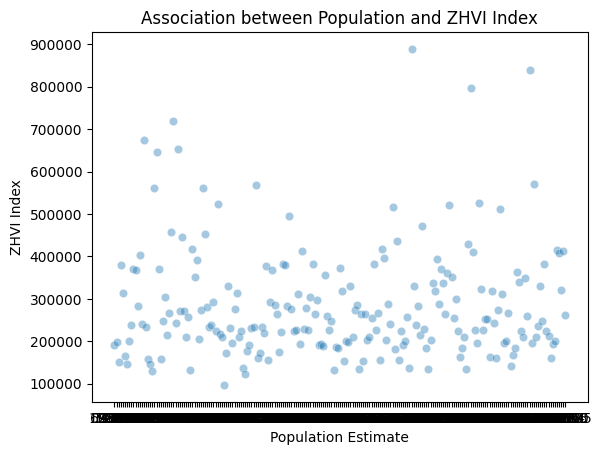

In [ ]:
# plotting association between population and ZHVI index
zhvi_pop = sns.scatterplot(
    data = merged_df,
    x = 'Population',
    y = 'Avg_Yearly_ZHVI',
    alpha = 0.4
)

# Customizing the plot
zhvi_pop.set_title("Association between Population and ZHVI Index")
zhvi_pop.set_xlabel("Population Estimate")
zhvi_pop.set_ylabel("ZHVI Index")

# Display the plot
plt.show()
plt.figure(figsize=(8,6))
plt.close() #